# ARMA(p,q) 살펴보기

**Recap** </br>
MA(q) 이동평균과정
- 현잿값: 평균, 현재 오차 항, 과거 오차 항에 선형적으로 의존
- q는 ACF 도식을 사용해 추론 가능
- 자기상관계수는 q까지만 유의
- ACF 도식이 천천히 감쇄하는 패턴이거나, 사인 곡선을 보이는 경우 MA가 아닌 AR이 존재할 수 있다. </br> 

AR(p) 자기회귀과정
- 현잿값: 과것값에 선형적으로 의존
    - 변수가 *자기 자신*에게 회귀적으로 의존
- PACF 도식을 활용해 편자기상관계수가 지연 p까지만 유의한지 확인 </br>

**자기회귀이동평균과정 (Autoregressive Moving Average Process) ARMA(p,q)**
- p: AR() 차수
- q: MA() 차수
- ACF와 PACF 도식을 사용해 q와 p를 결정하기에는 비슷한 패턴을 보여주기에 어려움. </br>

---

**ACF와 PACF의 한계 극복 방법: AIC, Q-Q Plot**
- 이를 해결하기 위해 **Akaike Information Criterian (AIC)** 을 통해 p와 q의 조합을 결정.
- 그 다음, 모델 잔차의 상관관계도인 **Quantile-Quantile Plot, Q-Q Plot** 을 통해 모델의 유효성 평가
    - 밀도 도식 검토
- 모델 잔차가 백색소음과 유사한지 평가하는 **잔차 분석 (Residual Analysis)**을 통해 모델의 $\underline{유효성}$ 평가.
- 유효하다면, ARMA(p,q)를 사용해 시계열 예측

# 6.1 데이터 센터의 대역폭 사용량 예측
---
단위: 초당 비트 (bits/sec)
- 예측할 수 있다면 컴퓨팅 자원을 더 잘 관리할 수 있음
    - 적게 사용할 것으로 예상되면 일부 컴퓨팅 자원을 종료 --> 비용 절감 & 유지 보수 용이

![alt text](Screenshots/6.2.png)

통상적인 절차:
- 데이터 수집
- 시계열 정상적인가?
     - 도식에 추세가 있다면 수열이 비정상적
     - ADF 테스트를 통해 정상성 확인 후 결과에 따라 변환 적용
- ACF 함수 도식화 (p 구하기 위해)
     - 지연 0 이후 유의한 자기상관계수가 있음 확인
        - 확률보행 아님
        - 계수가 서서히 감소하고 특정 지연을 지나 갑자기 유의하지 않게 되는 현상이 없으면, 순수한 MA가 아님.
- PACF 함수 도식화 (q 구하기 위해)
     - 사인 곡선 발견
          - 특정 지연 후 계수가 **갑자기** 유의하지 않게 되는 현상을 확인할 수 없다는 뜻
          - 순수한 AR이 아니다. </br>

앞으로는 AR과 MA의 조합: ARMA(p, q) 모델을 활용해 모델링. </br>
이상적으로 모델의 잔차는 백색소음과 유사한 특성.

# 6.2 자기회귀이동평균과정 살펴보기

AR과 마찬가지로 현잿값은 이전값과 상수에 **선형적**으로 의존,</br>
MA과 마찬가지로 **수열의 평균, 현재 오차, 과거 오차**에 선형적으로 의존.

Equation:</br>
$y_t = C + \phi_1 y_{t-1}+\phi_2 y_{t-2}+\phi_p y_{t-p}+\epsilon_t+\theta_1 \epsilon_{t-1}+\theta_2 \epsilon_{t-2}+\theta_q \epsilon_{t-q}$ </br>
상수 $C$, 수열의 과것값 $y_{t-p}$, ~~(수열의 평균 $\mu$,)~~ 과거 오차 항 $\epsilon_{t-q}$, 현재 오차 항 $\epsilon_t$의 선형 방정식으로 표현.

# 6.3 정상적 ARMA 프로세스 식별하기

ACF 도식, 그리고 PACF 도식을 확인하는 단계에서 두 가지 도식 모두에서 유의한 계수가 존재하다 갑자기 유의하지 않게 되는 명확한 지연 시점을 확인할 수 없다면, ARMA(p,q) 프로세스가 존재한다 할 수 있음. </br>

ex) ARMA(1, 1) </br>
$y_t = 0.33y_{t-1}+0.9\epsilon_{t-1}+\epsilon_t$ </br>
여기서 상수 C와 평균 $\mu$는 모두 0과 같다. (계수는 주관적인 선정)

목적: ARMA 프로세스의 차수 q를 식별하기 위해 ACF 도식을 사용할 수 없고, p를 식별하기 위해 PACF 도식을 사용할 수 없음을 입증.

In [2]:
from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np

np.random.seed(42)

ar1 = np.array([1, -0.33]) #ar은 항상 반대 부등호; 첫번째 계수는 항상 1
ma1 = np.array([1, 0.9])  #지연 0인 경우 첫번째 계수는 1

ARMA_1_1 = ArmaProcess(ar1, ma1).generate_sample(nsample = 1000) #1000개 샘플

In [ ]:
# 프로세스가 정상적인가?

from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(ARMA_1_1)

print(f'ADF Stats: {ADF_result[0]}')
print(f'ADF P-val: {ADF_result[1]}')

# 결과: ADF 통계 음수 & p-val이 0.05보다 훨씬 작으므로 ARMA(1,1) 프로세스는 정상적.

ADF Stats: -6.429878682042655
ADF P-val: 1.70784666801002e-08


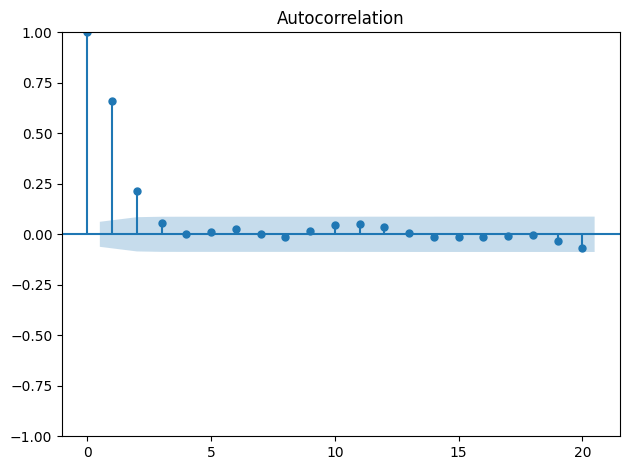

In [8]:
# ACF 도식화하고 ARMA(1,1)의 이동평균 부분의 차수를 유추할 수 있는가?

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(ARMA_1_1, lags=20)
plt.tight_layout()

AR(p) 프로세스 작동 중. 마지막으로 유의한 계수가 lag 2 이므로 q=2라고 추론할 수 있으나, 우리는 ARMA(1,1)을 시뮬했으니 q=1이어야 함. 그래서 ACF를 통해 ARMA(p,q)의 차수 q를 추론할 수 없음. </br>
ACF에서 사인 곡선 패턴이 있기에, 자기회귀과정이 있음을 나타냄. 

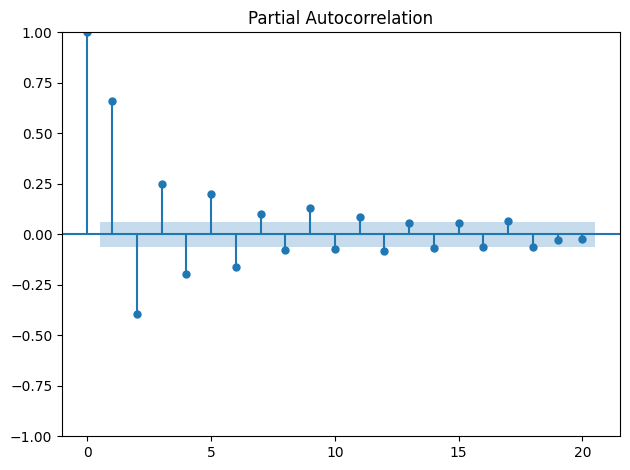

In [9]:
# PACF 도식화

from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(ARMA_1_1, lags=20)

plt.tight_layout()

유의한 계수와 유의하지 않은 계수를 명확히 구분할 수 없는 사인 곡선 패턴 보임. ARMA 프로세스의 p 차수가 1이라고 추론할 수 없으므로, PACF 도식을 사용해 ARMA(p,q) 차수 p를 추정할 수 없음. </br>

프로세스가 정상적이고 ACF & PACF에서 **모두** 감쇄하는 패턴이나 사인 곡선 패턴을 보이는 경우, 이는 정상적 ARMA(p,q) 프로세스.

# 6.4 일반적 모델링 절차 고안하기

ACF와 PACF 모두 사인곡선이나 감쇄 패턴을 보이면 해당 시계열을 ARMA(p,q)로 모델링 할 수 있음. 하지만 p와 q를 결정하는데 유용하지는 않음. 위에서는, 두 도식 모두 지연 1 이후에도 계수가 유의하다는 점을 알 수 있음.

장점: 
- 시계열이 비정상적이고, 계절성을 띄는 경우에도 적용해볼 수 있음.
- p 또는 q가 0인 경우에도 적합

![](Screenshots/6.6.png)

AIC: 각 모델의 품질 수준을 비교하는 정량적 기준. AIC가 가장 낮은 모델을 선택해야 함. </br>
이상적인 모델 선택시: 잔차는 백색소음처럼 보임 (예측값과 실젯값 사이의 차이가 무작위성에서 오기 때문; 즉, 잔차가 상관관계 없이 독립적으로 분포.)
- Q-Q도식와 Ljung-Box Test(융-박스 테스트)를 실행해 검증</br>

검증 결과 잔차가 완전히 무작위라는 결론이라면, 모델을 사용해 예측 수행 가능.
- 그렇지 않다면, p와 q에 대해 다른 값의 조합을 시도해보는 단계부터 다시 시작.

## 6.4.1 아카이케 정보 기준 이해하기

피팅해볼 모델 중 가장 적합한 모델 선택하는 방법.</br>
모델을 데이터에 피팅할 때 일부 정보는 손실되므로, AIC는 <u>모델에 의해 손실되는 정보의 양을 상대적으로 정량화</u>하고, <u>모델들을 정량적으로 비교</u>할 수 있음. </br>
손실된 정보다 적을수록 AIC 값은 낮고 모델이 더 우수하다 판정.

AIC = $2k - 2\ln(\hat{L})$ </br>
k는 추정 매개변수들의 개수, likelihood 함수의 최댓값 $\hat{L}$
- **낮을 수록 더 좋은 모델** <br>

$k = p + q$
- 차수 (p,q)가 증가함에 따라 매개변수의 개수 k가 증가하고, AIC도 증가
    - 더 복잡한 모델을 피팅할 수록 AIC 점수에 불이익.

Likelihood Function (가능도 함수)
- Goodness of Fit(적합도) 측정.
    - 확률 분포 함수(PDF; 매개변수가 정해진 모델에서 데이터 요소가 관측될 확률을 측정)의 반대 개념
        - ex) PDF는 주사위 숫자 중 하나가 관측될 확률이 1/6.
        - Likelihood Fn: 10번 굴려 [1,5,3,4,6,2,4,3,2,1] 나왔다면, likelihood fn은 주사위가 6면일 가능성을 결정
        - AIC에 적용한다면, likelihood fn은 **'내가 관측한 데이터가 ARMA(1,1) 모델에서 *나올 가능성이 얼마나 될까?*'라는 질문에 대한 답.**
        - $\hat{L}$이 크다면, ARMA(1,1) 모델이 데이터에 잘 맞는것.

모델이 데이터에 잘 맞으면, likelihood fn의 최댓값이 클것. </br>

---
모델의 매개변수의 개수와 훈련 데이터에 대한 적합도 사이에서 균형을 잡을 수 있음. </br>
AIC가 어떻게 underfitting, overfitting 사이에서 균형을 유지하는가?
- overfitting: goodness of fit (적합도)이 매우 높다 --> $\hat{L}$이 크다 --> AIC는 감소한다
    - 하지만 동시에 k도 커질 수 있어 AIC에 불이익을 줄 수도.
- underfitting: k가 작음
    - 하지만 적합도는 낮아 가능도 함수의 최댓값도 작아져 AIC가 불이익 받을 수도.

AIC는 다른 모델에 상대적으로 모델의 품질을 정량화한다.</br>
- 품질에 대한 상대적 척도.

## 6.4.2 AIC를 사용해 모델 선택

정상성 확인했으니, p와 q에 대해 가능한 값들의 목록을 정의하는 단계로 넘어가. </br>
p와 q의 값들이 0~3까지 범위에서 존재한다 가정. (여기서 임의지정; 원하면 더 큰 범위 가능)

In [11]:
from itertools import product

ps = range(0,4,1) #p값 목록; 0이상 4미만, 1씩 증가
qs = range(0,4,1)

order_list = list(product(ps,qs)) #가능한 모든 조합 생성 --> 16개

In [ ]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

#함수: 각 (p,q)조합과 그에 해당하는 AIC를 저장할 빈 목록을 초기화. 그 다음 각 (p,q) 조합에 대한 ARMA(p,q)모델을 데이터 피팅.
# AIC 계산하고 그 결과 저장. 그 다음 DataFrame을 생성하고, AIC 값이 낮을수록 더 좋은 모델이므로 AIC 값을 기준으로 오름차순으로 정렬.
def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame: #endog: 관측된 시계열 데이터
    results = [] #차수 (p,q)와 그에 해당하는 AIC를 tuple로 저장할 빈 목록 초기화.

    for order in tqdm_notebook(order_list): #모든 (p,q) 조합의 목록에 대해 for 루프. tqdm_notebook을 통해 진행률 표시.
        try:
            model = SARIMAX(endog, order = (order[0], 0, order[1]),
                            simple_differencing=False).fit(disp = False) #SARIMAX 함수를 사용해 ARMA(p,q) 모델 피팅. 차분이 되지 않도록 simple_differencing을 False.
                            # 콘솔에 상태 메시지 안 나오도록 disp = False.
        except:
            continue

        aic = model.aic #모델의 aic 계산.
        results.append([order,aic]) #결과 목록에 (p,q) 조합과 AIC를 튜플로 추가.

    result_df = pd.DataFrame(results) #(p,q) 조합과 AIC를 DataFrame에 저장
    result_df.columns = ['(p,q)', 'AIC'] #DataFrame의 열에 레이블 지정

    # ascending order as lower AIC is better
    result_df = result_df.sort_values(by = 'AIC', ascending = True).reset_index(drop = True) #AIC값을 기준으로 오름차순 정렬.

    return result_df

In [15]:
result_df = optimize_ARMA(ARMA_1_1, order_list)

result_df

/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_46417/3999661830.py:11: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list): #모든 (p,q) 조합의 목록에 대해 for 루프. tqdm_notebook을 통해 진행률 표시.


  0%|          | 0/16 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,"(p,q)",AIC
0,"(1, 1)",2801.407785
1,"(2, 1)",2802.906070
2,"(1, 2)",2802.967762
3,"(0, 3)",2803.666793
4,"(1, 3)",2804.524027
5,"(3, 1)",2804.588567
6,"(2, 2)",2804.822282
7,"(3, 3)",2805.990930
8,"(2, 3)",2806.175380
9,"(3, 2)",2806.894930


ARMA(1,1) 모델이 데이터에 피팅한 모든 모델들 중 상대적으로 가장 좋은 모델. 이제 절대적인 측정 방법이 필요.

### 여기서 질문: 왜 optimize_ARMA에 ARMA_1_1을 넣나요? 우리는 최고의 조합을 보는거 아닌가요?
차수가 박힌건 맞음. 하지만 이 정보는 ArmaProcess 객체와 내 머릿속에서만 알고, .generate_sample()이 뱉어낸 결과 배열 자체에는 전달이 안 됨.

## 6.4.3 잔차 분석 이해

절대적 품질 측정 </br>

**모델의 잔차: 예측값과 실젯값 간의 차이** </br>

답할 수 있는 질문:
1) Q-Q 도식이 직선을 나타내는가?
2) 잔차들이 상관관계가 없는가? </br>

모두 yes --> 예측 수행 준비 된 모델 </br>
하나라도 no --> 다른 (p,q) 조합들에 대해 시도

$y_t = 0.33y_{t-1}+0.9\epsilon{t-1}+\epsilon_t$ 를 활용해, 우리가 ARMA(1,1) 모델을 원래의 프로세스에 피팅한 뒤 모델 계수를 완벽하게 추정했다고 한다면, </br>
$\hat{y}=0.33y_{t-1}+0.9\epsilon_{t-1}$ </br>
잔차는 모델에서 나온 값과 시뮬된 프로세스의 실젯값 사이의 차이. 즉 위 두 식의 차이.</br>
residuals = $0.33y_{t-1}+0.9\epsilon{t-1}+\epsilon_t - (0.33y_{t-1}+0.9\epsilon_{t-1})$ </br>
residuals = $\epsilon_t$

완벽하게 모델을 선택한 상황에서 모델의 잔차는 **백색소음**.
- 모델이 모든 예측 정보를 포착해 모델링할 수 없는 무작위한 변동만 남았다는 뜻.
- 잔차들이 서로 상관관계가 없고 정규분포를 가진다면, 좋은 예측 결과를 보일 모델이라 결론.

잔차 분석
- 질적 분석: Q-Q 도식
- 양적 분석: 잔차들 간의 상관관계 유무

### 정성적 분석: Q-Q 도식 확인

Q-Q 도식: 모델의 잔차가 <u>정규분포</u>라는 가설을 검증하기 위한 시각적 도구.  
- 이론적 분포인 정규분포의 사분위수를 x-축 (왜 정규분포? 잔차가 정규분포인 백색소음에 가깝기를 바라기 때문)
- 잔차(샘플)의 사분위수를 y-축에 그려 구성  
- 결과: 산점도 생성

잔차의 분포가 정규분포에 가까우면 Q-Q 도식은 y=x와 거의 동일한 직선. 모델이 데이터에 잘 피팅 되었다는 뜻.  

### 정량적 분석: 융-박스 테스트

Ljung-Box Test: 데이터 집단의 자기상관관계가 0과 유의하게 다른지 테스트하는 통계 검사.
- Null Hypothesis: 데이터가 독립적으로 분포 & 자기상관관계가 없다
    - p-val이 0.05 미만이면, 귀무가설 기각 --> 잔차가 독립적으로 분포되어 있지 않고 상관관계가 있음을 뜻함. 이런 모델은 예측 사용 불가.  

모델의 잔차들간의 상관관게가 없음을 증명하기 위한 수단.  
좋은 모델: 잔차가 백색소음에 가까우므로, 잔차가 정규분포이고 잔차들 간의 상관관게가 없어야 한다.  


## 6.4.4 잔차 분석 수행 (Q-Q Plot & Ljung-Box Test) 
ARMA(1,1) 프로세스에 대한 모델링 절차. 가장 낮은 AIC 모델을 선택했는데, 예상대로 ARMA(1,1) 모델.  
여기서는 모델링 절차가 제대로 작동하는지 확인.  

잔차 분석 수행 위해:
- 모델을 피팅 & 잔차에 쉽게 접근할 수 있도록 변수에 저장. ARMA(1,1) 모델을 정의한 후 시뮬레이션된 데이터에 피팅.
- 그 다음 잔차에 접근

In [16]:
model = SARIMAX(ARMA_1_1, order=(1,0,1), simple_differencing=False)
model_fit = model.fit(disp=False)
residuals = model_fit.resid #모델의 잔차 저장

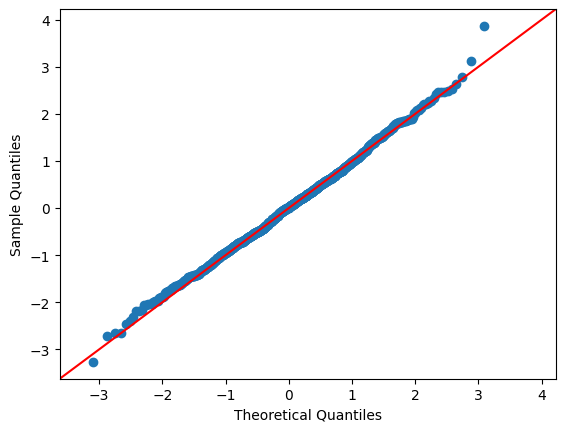

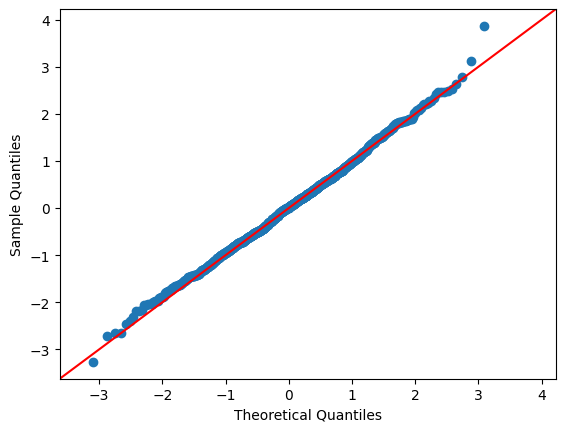

In [18]:
# Q-Q 도식 그리기
from statsmodels.graphics.gofplots import qqplot

qqplot(residuals, line='45') #y=x 직선을 표시하도록 설정.

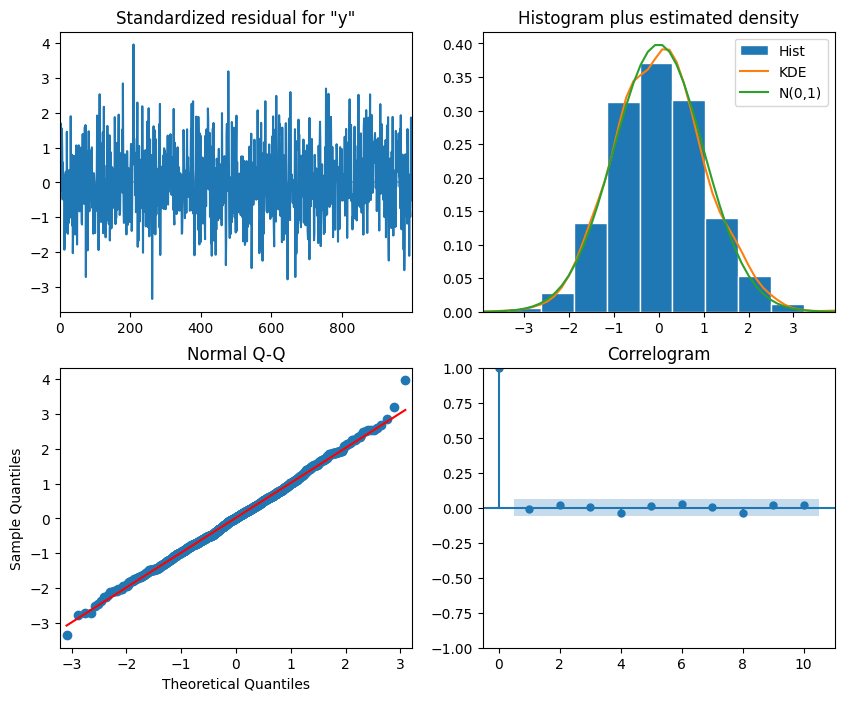

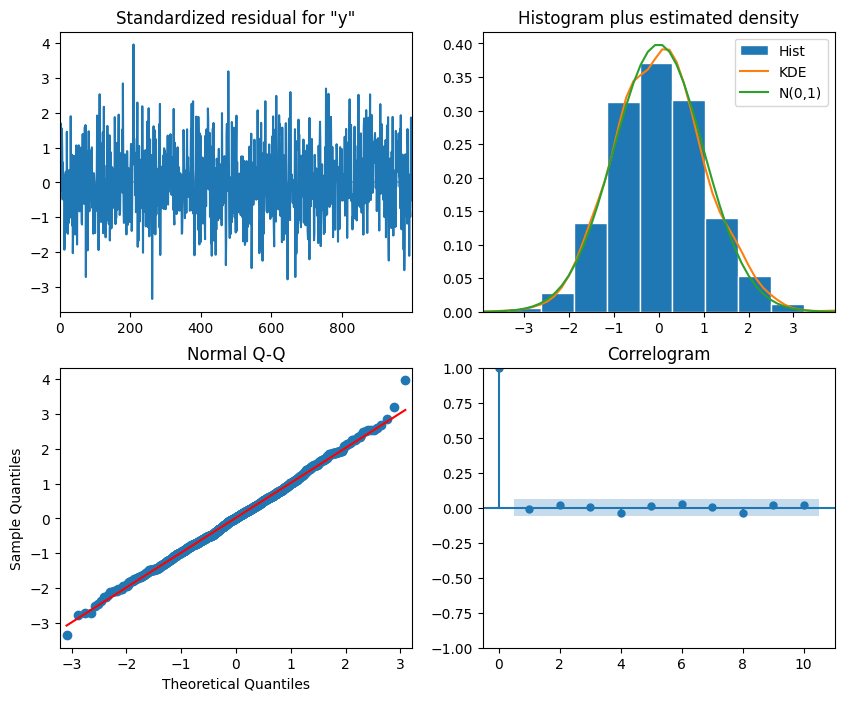

In [19]:
# 이제 정성적 분석. 
model_fit.plot_diagnostics(figsize = (10,8))

왼쪽 상단: 데이터 집합의 잔차; 특이한 추세 없고, 평균 시간 지나도 안정적으로 백섹소음과 같은 정상성  
오른쪽 상단: 잔차의 히스토그램; 정규분포 확인했고, 백색소음도 정규분포이므로 잔차가 백색소음에 가깝다는 것을 나타냄  
왼쪽 하단: Q-Q 도식  
오른쪽 하단: 잔차의 자기상관함수; 지연 0에서만 유의미 한 피크 & 나머지는 유의한 계수가 없음 --> **잔차에 상관관계가 없음을 뜻하니 백색소음에 가까워 적절한 모델이다**라는 결론

In [22]:
# Ljung-Box Test
# 잔차에 실제로 상관관계가 없는지 정량적으로 평가
from statsmodels.stats.diagnostic import acorr_ljungbox

tr = acorr_ljungbox(residuals, np.arange(1, 11, 1)) #10개의 지연에 대한 잔체에 대해 융-박스 테스트 

print(tr) #각 지연에 대한 p-값 표시

     lb_stat  lb_pvalue
1   0.030706   0.860897
2   0.528021   0.767966
3   0.540904   0.909817
4   2.079774   0.721089
5   2.271897   0.810385
6   2.896262   0.821750
7   2.900378   0.894063
8   4.418799   0.817501
9   4.787567   0.852419
10  5.246805   0.874093


해석:
- p-val이 0.05 초과 --> 귀무가설 기각 불가 --> 잔차가 독립적으로 분포하고 상관관계가 없음을 의미.  

**결과: 잔차가 백색소음과 유사하다는 결론. 잔차는 완전히 무작위, 데이터에 잘 맞는 모델이다.**
- Q-Q 도식은 직선 --> 잔차가 정규분포되어 있다
- Ljung-Box Test 잔차가 백색소음과 마찬가지로 상관관계가 없음  

# 6.5 일반적 모델링 절차 적용하기

이제 대역폭 데이터 집합에 동일한 절차를 적용해 이 상황에 가장 적합한 모델을 얻어보자.  
**목표: 향후 2시간 동안의 대역폭 사용량을 예측.**  

In [23]:
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/bandwidth.csv')
df

,hourly_bandwidth
0,1000.496714
1,1000.969408
2,1002.046019
3,1004.702118
4,1007.447816
...,...
9995,740.546059
9996,738.906228
9997,736.057995
9998,733.559640


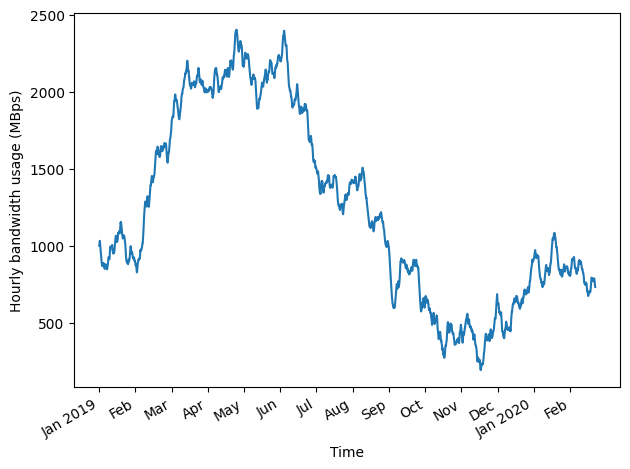

In [25]:
fig, ax = plt.subplots()

ax.plot(df.hourly_bandwidth)
ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwidth usage (MBps)')

plt.xticks(
    np.arange(0, 10000, 730),
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 
     'Nov', 'Dec', 'Jan 2020', 'Feb']
)

fig.autofmt_xdate()
plt.tight_layout()

도식: 주기적인 패턴은 없으나, 장기적인 추세 발견 --> 데이터 비정상적일 가능성 높다.  
ADF 테스트로.

In [26]:
ADF_result = adfuller(df['hourly_bandwidth'])

print(f'ADF Stats: {ADF_result[0]}')
print(f'ADF p-val: {ADF_result[1]}')

ADF Stats: -0.8714653199452732
ADF p-val: 0.7972240255014552


-0.8의 ADF 통계와 0.80의 p-val. 시계열이 비정상적이라는 뜻인 귀무가설 기각할 수 없음.  
정상적으로 변환 필요.

In [27]:
bandwidth_diff = np.diff(df.hourly_bandwidth, n=1)

차분된 데이터 다시 수용하여 정상성 재확인

In [28]:
ADF_result = adfuller(bandwidth_diff)

print(f'ADF Stats: {ADF_result[0]}')
print(f'ADF p-val: {ADF_result[1]}')

ADF Stats: -20.69485386378901
ADF p-val: 0.0


이제 수열이 정상적이다라고 말할 수 있음.  
이제 ARMA(p,q) 모델을 사용해 정상적 프로세스를 모델링할 준비.  
- 수열을 훈련집합과 테스트 집합으로 분할.
- 테스트 집합: 지난 7일간의 데이터 포함
- 예측: 향후 2시간. 테스트 집합에 포함한 7일간의 시간별 데이터는 168시간 (7*24) --> 테스트 집합에는 모델의 성능을 평가할 수 있는 <u>2시간 단계</u>의 <u>84개 기간</u>이 포함 (84개 기간 * 2단계 = 168시간).  

In [29]:
df_diff = pd.DataFrame({'bandwidth_diff': bandwidth_diff})

train = df_diff[:-168]
test = df_diff[-168:]

print(len(train))
print(len(test))

9831
168


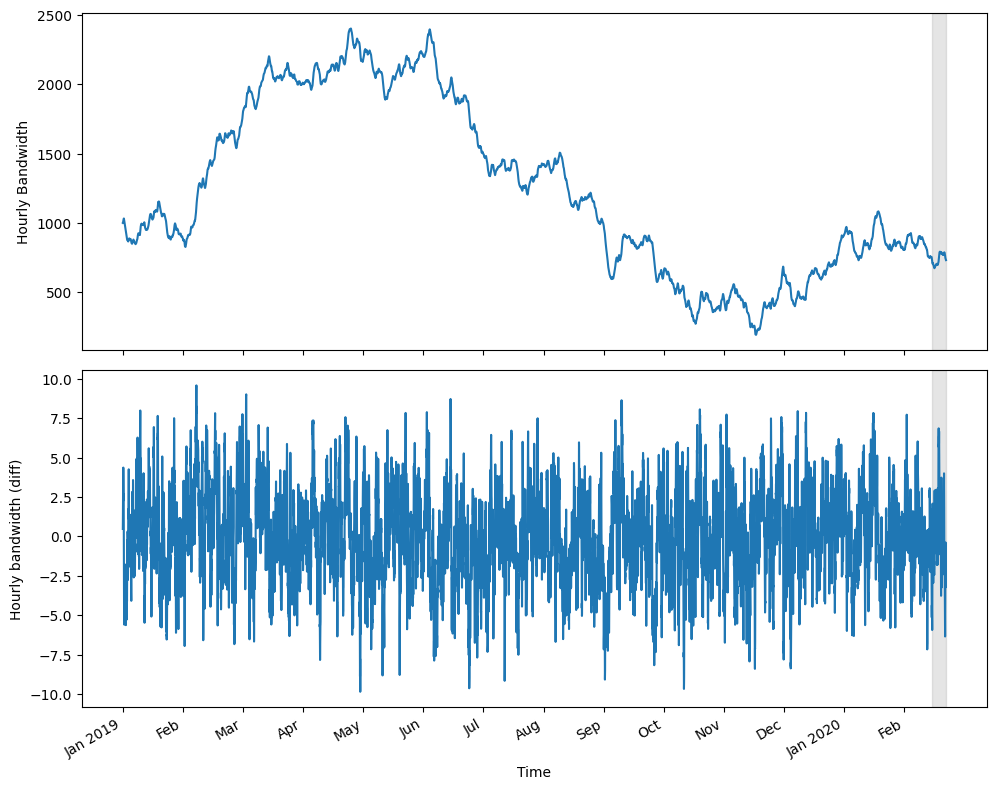

In [30]:
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, sharex = True, figsize = (10, 8))

ax1.plot(df.hourly_bandwidth)
ax1.set_xlabel('Time')
ax1.set_ylabel('Hourly Bandwidth')
ax1.axvspan(9831, 10000, color = '#808080', alpha = 0.2)

ax2.plot(df_diff.bandwidth_diff)
ax2.set_xlabel('Time')
ax2.set_ylabel('Hourly bandwidth (diff)')
ax2.axvspan(9830, 9999, color = '#808080', alpha = 0.2)

plt.xticks(
    np.arange(0, 10000, 730),
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 
     'Nov', 'Dec', 'Jan 2020', 'Feb']
)

fig.autofmt_xdate()
plt.tight_layout()